INFO       width adjusted from 20. ms to 20.1 ms [brian2.monitors.ratemonitor.adjusted_width]


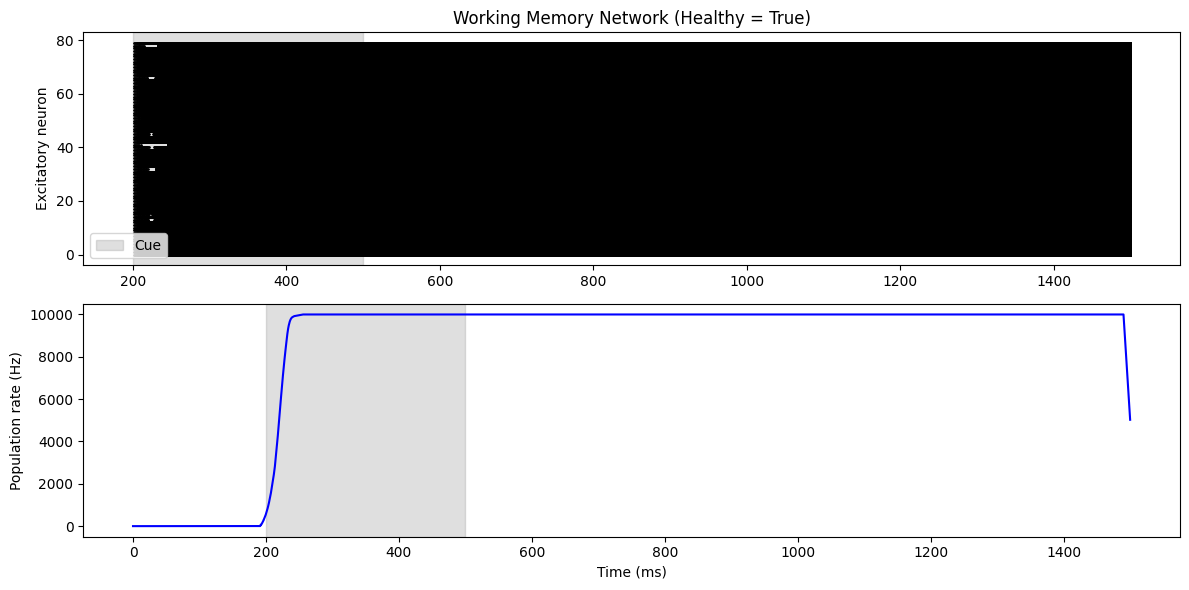

In [1]:
from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# ==========================================================
# Toggle
# ==========================================================

is_healthy = True

# ==========================================================
# Network size
# ==========================================================

N_exc = 80
N_inh = 20

# ==========================================================
# Membrane parameters
# ==========================================================

tau_m = 20*ms

v_rest = -65*mV
v_reset = -65*mV
v_threshold = -50*mV

R = 100*Mohm

# ==========================================================
# Synaptic reversal potentials
# ==========================================================

E_exc = 0*mV
E_inh = -80*mV

# ==========================================================
# Synaptic time constants
# ==========================================================

tau_nmda = 100*ms
tau_gaba = 10*ms

# ==========================================================
# Disease parameters
# ==========================================================

if is_healthy:

    nmda_strength = 0.05
    inhibition_strength = 0.12
    sigma = 1.2*mV

else:

    # NMDA hypofunction
    nmda_strength = 0.018

    # weaker inhibitory recruitment
    inhibition_strength = 0.08

    # noisier cortex
    sigma = 2.2*mV

# ==========================================================
# Neuron equations
# ==========================================================

eqs = '''

dv/dt = (
(v_rest-v)
+ g_nmda*(E_exc-v)
+ g_gaba*(E_inh-v)
+ R*I_ext
)/tau_m
+ sigma*xi*tau_m**-0.5 : volt

dg_nmda/dt = -g_nmda/tau_nmda : 1

dg_gaba/dt = -g_gaba/tau_gaba : 1

I_ext : amp

'''

# ==========================================================
# Populations
# ==========================================================

Exc = NeuronGroup(
    N_exc,
    eqs,
    threshold='v>v_threshold',
    reset='v=v_reset',
    method='euler'
)

Inh = NeuronGroup(
    N_inh,
    eqs,
    threshold='v>v_threshold',
    reset='v=v_reset',
    method='euler'
)

Exc.v = v_rest
Inh.v = v_rest

Exc.I_ext = 0*nA
Inh.I_ext = 0*nA

# ==========================================================
# Recurrent excitation (NMDA)
# ==========================================================

EE = Synapses(
    Exc,
    Exc,
    on_pre=f'g_nmda += {nmda_strength}'
)

EE.connect(p=0.25)

# ==========================================================
# Excitatory → inhibitory
# ==========================================================

EI = Synapses(
    Exc,
    Inh,
    on_pre='g_nmda += 0.04'
)

EI.connect(p=0.4)

# ==========================================================
# Inhibitory → excitatory
# ==========================================================

IE = Synapses(
    Inh,
    Exc,
    on_pre=f'g_gaba += {inhibition_strength}'
)

IE.connect(p=0.5)

# ==========================================================
# Inhibitory recurrent
# ==========================================================

II = Synapses(
    Inh,
    Inh,
    on_pre='g_gaba += 0.05'
)

II.connect(p=0.4)

# ==========================================================
# Background cortical activity
# ==========================================================

background = PoissonGroup(N_exc+N_inh, rates=5*Hz)

bg_exc = Synapses(
    background,
    Exc,
    on_pre='g_nmda += 0.015'
)

bg_exc.connect(j='i if i < N_exc')

bg_inh = Synapses(
    background,
    Inh,
    on_pre='g_nmda += 0.015'
)

bg_inh.connect(j='i-N_exc if i>=N_exc')

# ==========================================================
# Monitors
# ==========================================================

spike_exc = SpikeMonitor(Exc)

rate_exc = PopulationRateMonitor(Exc)

# ==========================================================
# Phase A : Rest
# ==========================================================

run(200*ms)

# ==========================================================
# Phase B : Cue
# ==========================================================

Exc.I_ext = 2*nA

run(300*ms)

# ==========================================================
# Phase C : Delay
# ==========================================================

Exc.I_ext = 0*nA

run(1000*ms)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)

plt.plot(spike_exc.t/ms,
         spike_exc.i,
         '.k',
         markersize=2)

plt.axvspan(
    200,
    500,
    color='gray',
    alpha=0.25,
    label='Cue'
)

plt.ylabel("Excitatory neuron")

plt.title(
    f"Working Memory Network (Healthy = {is_healthy})"
)

plt.legend()

plt.subplot(2,1,2)

smooth = rate_exc.smooth_rate(
    window='flat',
    width=20*ms
)

if is_healthy:
    plt.plot(rate_exc.t/ms, smooth, 'b')
else:
    plt.plot(rate_exc.t/ms, smooth, 'r')

plt.axvspan(
    200,
    500,
    color='gray',
    alpha=0.25
)

plt.xlabel("Time (ms)")
plt.ylabel("Population rate (Hz)")

plt.tight_layout()
plt.show()

WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File 'C:\Users\avish\AppData\Local\Temp\ipykernel_17980\2638417070.py', line 43, in <module>
    S = Synapses(G, G, 'w : amp', on_pre='I_syn += w') [brian2.core.base.unused_brian_object]


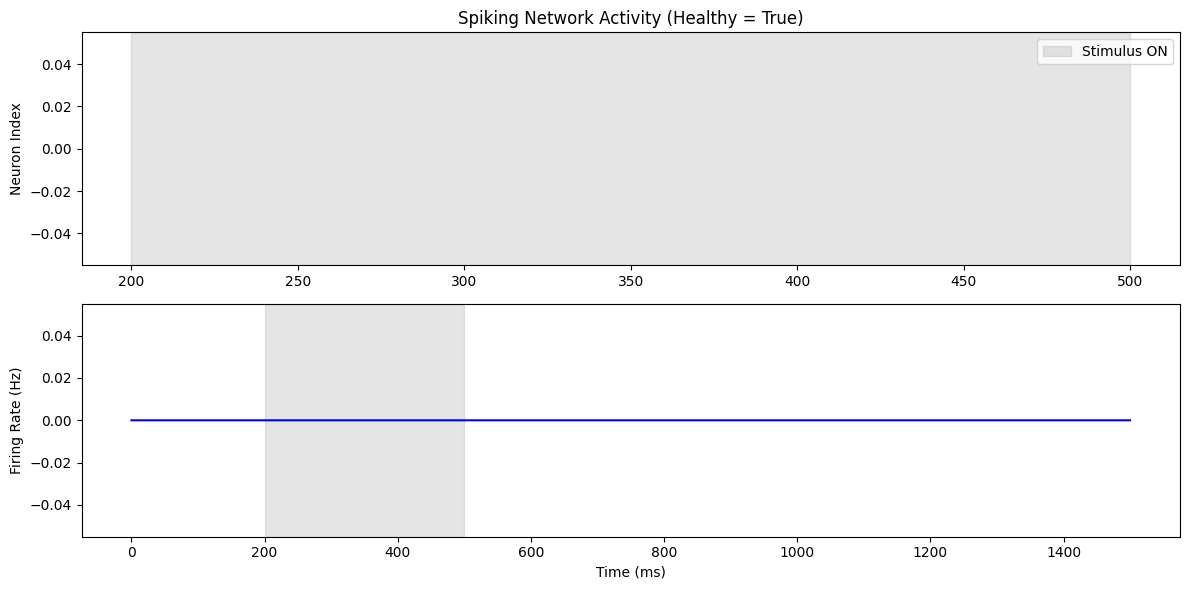

In [8]:


from brian2 import *
import matplotlib.pyplot as plt
prefs.codegen.target = 'numpy'

# --- 1. Simulation Setup ---
# Brian2 requires physical units (ms, mV, nA). This is its greatest strength.
start_scope() 

# --- 2. Biological Parameters ---
N_neurons = 100 # A small prefrontal microcircuit
tau_m = 20*ms # Membrane time constant (how fast the neuron charges)
v_rest = -65*mV # Resting potential of a human neuron
v_threshold = -50*mV # The voltage needed to fire a spike
v_reset = -65*mV # Voltage drops back to rest after firing
tau_nmda = 100*ms # The "Wang" magic: NMDA stays open for a long time!
R = 100*Mohm #added membrane resistance

# --- 3. The Condition Toggle (Your Schizophrenia Knob) ---
# CHANGE THIS TO FALSE to see the Schizophrenic brain!
is_healthy = True 

if is_healthy:
    nmda_weight = 0.08 * nA # Strong NMDA: The "glue" holds the thought
else:
    nmda_weight = 0.04 * nA # Weak NMDA: The 50% deficit in Schizophrenia

# --- 4. The Neuron Equations (Leaky Integrate-and-Fire) ---
# This is the biological physics. Voltage changes based on background noise, 
# the stimulus (cue), and the recurrent NMDA currents from its neighbors.
eqs = '''
dv/dt = (v_rest - v + (I_syn + I_cue + I_noise) * Mohm) / tau_m : volt
dI_syn/dt = -I_syn / tau_nmda : amp # NMDA current decays slowly over time
I_cue : amp # External stimulus (The thing to remember)
I_noise : amp # Background brain static
'''

# Create the population of neurons
G = NeuronGroup(N_neurons, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest # Start everyone at resting potential

# --- 5. The Recurrent "Working Memory" Circuit ---
# Neurons connect to each other. When one fires, it adds 'nmda_weight' to the neighbor's I_syn.
S = Synapses(G, G, 'w : amp', on_pre='I_syn += w')
S.connect(p=0.3) # 30% probability of any two neurons being connected
S.w = nmda_weight

# --- 6. The Monitors (The "EEG" and "Electrodes") ---
# These record what happens during the simulation so we can plot it later.
spike_monitor = SpikeMonitor(G) # Records exact spike times
rate_monitor = PopulationRateMonitor(G) # Records the average firing rate

# --- 7. The Clinical Trial (The Timeline) ---

# Phase A: Resting State (0 to 200 ms)
# The brain is just dealing with random background noise.
G.I_noise = '0.05 * nA * randn()'
run(200*ms)

# Phase B: The CUE (200 ms to 500 ms)
# We show the patient the image they need to remember.
G.I_cue = 0.2 * nA 
run(300*ms)

# Phase C: The DELAY / Memory Phase (500 ms to 1500 ms)
# We turn the cue off. If NMDA is strong, the recurrent circuit will keep firing!
G.I_cue = 0 * nA
run(1000*ms)

# --- 8. Plotting the Results ---
plt.figure(figsize=(12, 6))

# Top Plot: The Spike Raster (Looking at individual neurons)
plt.subplot(2, 1, 1)
plt.plot(spike_monitor.t/ms, spike_monitor.i, '.k', markersize=2)
plt.axvspan(200, 500, color='gray', alpha=0.2, label='Stimulus ON')
plt.title(f'Spiking Network Activity (Healthy = {is_healthy})')
plt.ylabel('Neuron Index')
plt.legend(loc='upper right')

# Bottom Plot: The Population Rate (Matches your RK4 "S1" variable!)
plt.subplot(2, 1, 2)
# We smooth the rate so it looks cleaner, just like real EEG data
smoothed_rate = rate_monitor.smooth_rate(window='flat', width=20.1*ms)
plt.plot(rate_monitor.t/ms, smoothed_rate, 'b' if is_healthy else 'r')
plt.axvspan(200, 500, color='gray', alpha=0.2)
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()



In [10]:


from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# --- Parameters ---
N = 100
tau_m = 20*ms
v_rest = -65*mV
v_threshold = -50*mV
v_reset = -65*mV
R = 100*Mohm
tau_nmda = 100*ms

is_healthy = True
nmda_w = 0.05*mV if is_healthy
else 0.015*mV # Simplified for voltage-based synapses

# --- Equations ---
# We simplify the synapse to be voltage-based (easier to tune initially)
eqs = '''
dv/dt = (v_rest - v + g_nmda*(v_rest - v)) / tau_m : volt
dg_nmda/dt = -g_nmda / tau_nmda : 1
I_ext = amp
'''

G = NeuronGroup(N, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest
G.g_nmda = 0

# --- Recurrent Connections ---
S = Synapses(G, G, on_pre='g_nmda += nmda_w') # Internal 'glue'
S.connect(p=0.3)

# --- THE POISSON INPUT (The Cue) ---
# This acts as an external population 'firing' at our neurons
# 100 Hz is a strong signal to ensure they wake up!
cue = PoissonInput(G, 'g_nmda', 1, 100*Hz, weight=0.5)

# --- Monitors ---
spikes = SpikeMonitor(G)
rate = PopulationRateMonitor(G)

# --- Run ---
run(200*ms) # Baseline
# To simulate the 'CUE ON/OFF', we use the 'active' attribute
cue.active = True
run(300*ms) # Cue on
cue.active = False
run(1000*ms) # Delay period

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.subplot(2,1,1)
plt.plot(spikes.t/ms, spikes.i, '.k')
plt.title(f'Poisson-Driven Network (Healthy={is_healthy})')
plt.subplot(2,1,2)
plt.plot(rate.t/ms, rate.smooth_rate(window='flat', width=20*ms)/Hz)
plt.ylabel('Rate (Hz)')
plt.show()



SyntaxError: expected 'else' after 'if' expression (2691944029.py, line 17)

In [ ]:


from brian2 import *
import matplotlib.pyplot as plt
prefs.codegen.target = 'numpy'

# --- 1. Simulation Setup ---
# Brian2 requires physical units (ms, mV, nA). This is its greatest strength.
start_scope() 

# --- 2. Biological Parameters ---
N_neurons = 100 # A small prefrontal microcircuit
tau_m = 20*ms # Membrane time constant (how fast the neuron charges)
v_rest = -65*mV # Resting potential of a human neuron
v_threshold = -50*mV # The voltage needed to fire a spike
v_reset = -65*mV # Voltage drops back to rest after firing
tau_nmda = 100*ms # The "Wang" magic: NMDA stays open for a long time!
R = 100*Mohm #added membrane resistance

# --- 3. The Condition Toggle (Your Schizophrenia Knob) ---
# CHANGE THIS TO FALSE to see the Schizophrenic brain!
is_healthy = True 

if is_healthy:
    nmda_weight = 0.08 * nA # Strong NMDA: The "glue" holds the thought
else:
    nmda_weight = 0.04 * nA # Weak NMDA: The 50% deficit in Schizophrenia

# --- 4. The Neuron Equations (Leaky Integrate-and-Fire) ---
# This is the biological physics. Voltage changes based on background noise, 
# the stimulus (cue), and the recurrent NMDA currents from its neighbors.
eqs = '''
dv/dt = (v_rest - v + (I_syn + I_cue + I_noise) * Mohm) / tau_m : volt
dI_syn/dt = -I_syn / tau_nmda : amp # NMDA current decays slowly over time
I_cue : amp # External stimulus (The thing to remember)
I_noise : amp # Background brain static
'''

# Create the population of neurons
G = NeuronGroup(N_neurons, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest # Start everyone at resting potential

# --- 5. The Recurrent "Working Memory" Circuit ---
# Neurons connect to each other. When one fires, it adds 'nmda_weight' to the neighbor's I_syn.
S = Synapses(G, G, 'w : amp', on_pre='I_syn += w')
S.connect(p=0.3) # 30% probability of any two neurons being connected
S.w = nmda_weight

# --- 6. The Monitors (The "EEG" and "Electrodes") ---
# These record what happens during the simulation so we can plot it later.
spike_monitor = SpikeMonitor(G) # Records exact spike times
rate_monitor = PopulationRateMonitor(G) # Records the average firing rate

# --- 7. The Clinical Trial (The Timeline) ---

# Phase A: Resting State (0 to 200 ms)
# The brain is just dealing with random background noise.
G.I_noise = '0.05 * nA * randn()'
run(200*ms)

# Phase B: The CUE (200 ms to 500 ms)
# We show the patient the image they need to remember.
G.I_cue = 0.2 * nA 
run(300*ms)

# Phase C: The DELAY / Memory Phase (500 ms to 1500 ms)
# We turn the cue off. If NMDA is strong, the recurrent circuit will keep firing!
G.I_cue = 0 * nA
run(1000*ms)

# --- 8. Plotting the Results ---
plt.figure(figsize=(12, 6))

# Top Plot: The Spike Raster (Looking at individual neurons)
plt.subplot(2, 1, 1)
plt.plot(spike_monitor.t/ms, spike_monitor.i, '.k', markersize=2)
plt.axvspan(200, 500, color='gray', alpha=0.2, label='Stimulus ON')
plt.title(f'Spiking Network Activity (Healthy = {is_healthy})')
plt.ylabel('Neuron Index')
plt.legend(loc='upper right')

# Bottom Plot: The Population Rate (Matches your RK4 "S1" variable!)
plt.subplot(2, 1, 2)
# We smooth the rate so it looks cleaner, just like real EEG data
smoothed_rate = rate_monitor.smooth_rate(window='flat', width=20.1*ms)
plt.plot(rate_monitor.t/ms, smoothed_rate, 'b' if is_healthy else 'r')
plt.axvspan(200, 500, color='gray', alpha=0.2)
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()



In [11]:

from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# 1. Biological Parameters
N = 100
tau_m = 20*ms
v_rest = -65*mV
v_threshold = -50*mV
v_reset = -65*mV
E_exc = 0*mV # The critical fix: Excitatory reversal potential
tau_nmda = 100*ms

# 2. The Condition Toggle
is_healthy = True 
nmda_w = 0.05 if is_healthy else 0.015

# 3. The Neuron Equations
# Now g_nmda multiplies (E_exc - v), pulling the voltage up toward 0 mV!
eqs = '''
dv/dt = (v_rest - v + g_nmda * (E_exc - v) + I_ext/nS) / tau_m : volt
dg_nmda/dt = -g_nmda / tau_nmda : 1
I_ext : amp
'''

G = NeuronGroup(N, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest
G.g_nmda = 0

# 4. Recurrent Connections
S = Synapses(G, G, on_pre='g_nmda += nmda_w')
S.connect(p=0.3)

# 5. Monitors
spikes = SpikeMonitor(G)
rate = PopulationRateMonitor(G)

# 6. The Clinical Trial Protocol

# Phase A: Rest
G.I_ext = 0*nA
run(200*ms)

# Phase B: The Cue (Injecting a strong current to force initial firing)
G.I_ext = 2*nA
run(300*ms)

# Phase C: The Delay / Memory Phase
G.I_ext = 0*nA
# Adding continuous random biological noise to test attractor stability
G.run_regularly('v += 1.5*mV * randn()', dt=1*ms)
run(1000*ms)

# 7. Plotting
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(spikes.t/ms, spikes.i, '.k', markersize=2)
plt.axvspan(200, 500, color='gray', alpha=0.2, label='Stimulus ON')
plt.title(f'Spiking Network Activity (Healthy = {is_healthy})')
plt.ylabel('Neuron Index')
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
smoothed_rate = rate.smooth_rate(window='flat', width=20.1*ms)
plt.plot(rate.t/ms, smoothed_rate, 'b' if is_healthy else 'r')
plt.axvspan(200, 500, color='gray', alpha=0.2)
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()



MagicError: The magic network contains a mix of objects that has been run before and new objects, Brian does not know whether you want to start a new simulation or continue an old one. Consider explicitly creating a Network object. Also note that you can find out which objects will be included in a magic network with the collect() function.

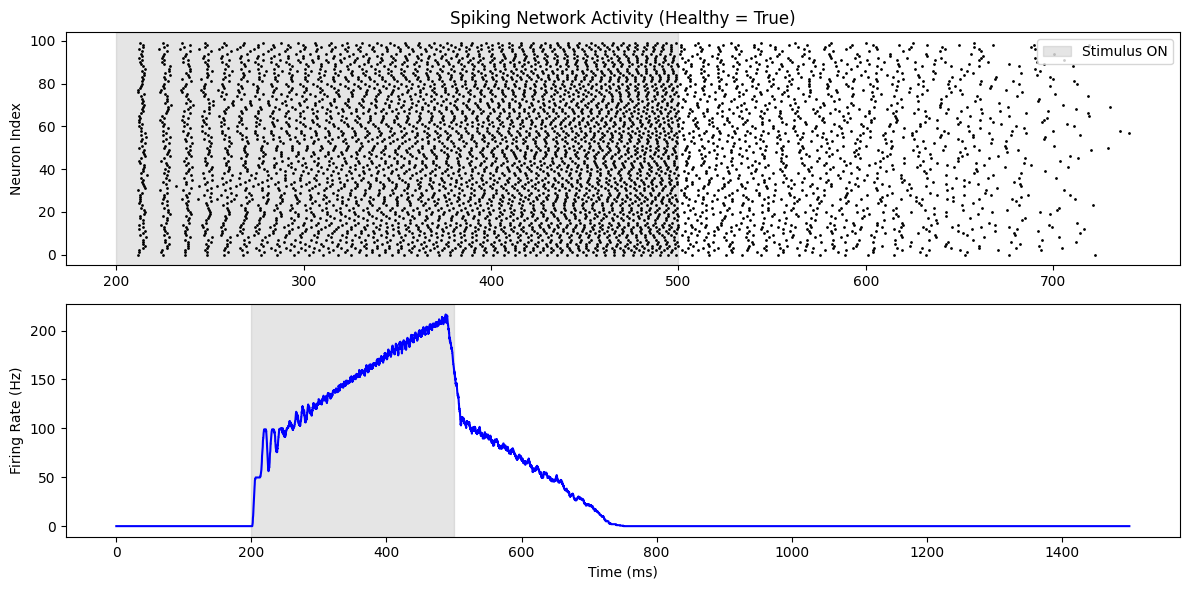

In [37]:
from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# Biological Parameters
N = 100
tau_m = 20*ms
v_rest = -65*mV
v_threshold = -50*mV
v_reset = -65*mV
E_exc = 0*mV               
tau_nmda = 100*ms
R = 100*Mohm
sigma = 1.5*mV # The amplitude of our biological noise

# The Condition Toggle
is_healthy = True 
nmda_w = 0.0009 if is_healthy else 0.00085

# The Neuron Equations
# xi represents continuous stochastic noise in Brian2
eqs = '''
dv/dt = (v_rest - v + g_nmda * (E_exc - v) + R*I_ext) / tau_m + sigma*xi*tau_m**-0.5 : volt
dg_nmda/dt = -g_nmda / tau_nmda : 1
I_ext : amp
'''

G = NeuronGroup(N, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest
G.g_nmda = 0

# Recurrent Connections
S = Synapses(G, G, on_pre='g_nmda += nmda_w')
S.connect(p=0.5)

# Monitors
spikes = SpikeMonitor(G)
rate = PopulationRateMonitor(G)

# Phase A: Rest
G.I_ext = 0*nA
run(200*ms)

# Phase B: The Cue
G.I_ext = 0.3*nA
run(300*ms)

# Phase C: The Delay / Memory Phase
G.I_ext = 0*nA
run(1000*ms)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(spikes.t/ms, spikes.i, '.k', markersize=2)
plt.axvspan(200, 500, color='gray', alpha=0.2, label='Stimulus ON')
plt.title(f'Spiking Network Activity (Healthy = {is_healthy})')
plt.ylabel('Neuron Index')
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
smoothed_rate = rate.smooth_rate(window='flat', width=20.1*ms)
plt.plot(rate.t/ms, smoothed_rate, 'b' if is_healthy else 'r')
plt.axvspan(200, 500, color='gray', alpha=0.2)
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()

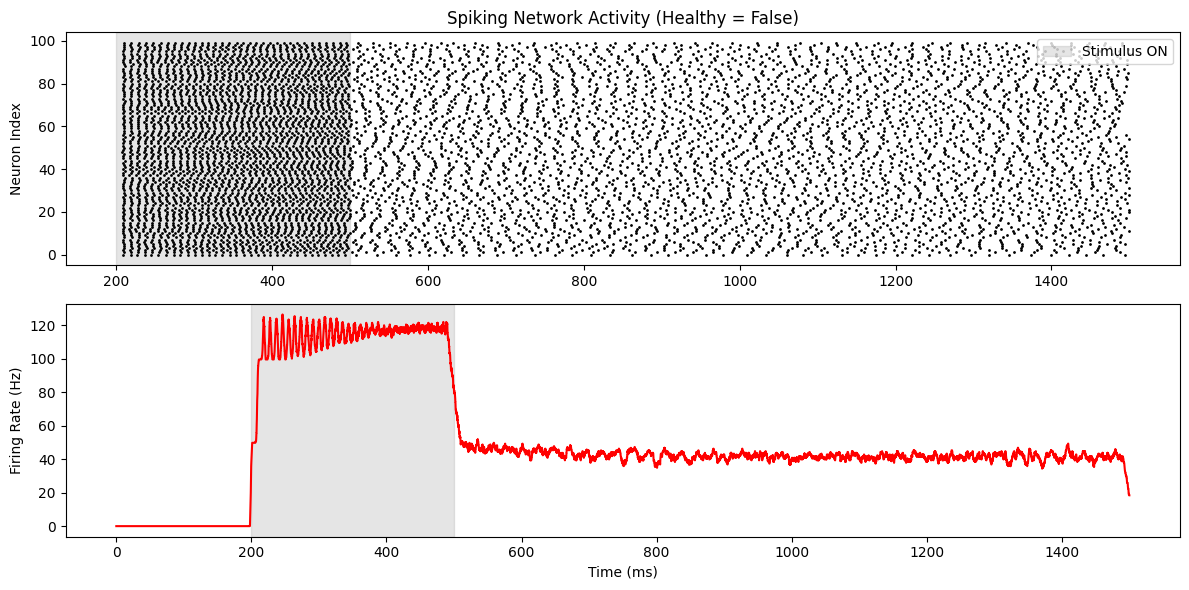

In [24]:
#HEALTHY BUT EXCITABLE MOVING TOWARDS SCHIZOPHRENIA

from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# Biological Parameters
N = 100
tau_m = 20*ms
v_rest = -65*mV
v_threshold = -50*mV
v_reset = -65*mV
E_exc = 0*mV               
tau_nmda = 100*ms
R = 100*Mohm
sigma = 1.5*mV # The amplitude of our biological noise

# The Condition Toggle
is_healthy = False
nmda_w = 0.0008 if is_healthy else 0.0002

# The Neuron Equations
# xi represents continuous stochastic noise in Brian2
eqs = '''
dv/dt = (v_rest - v + g_nmda * (E_exc - v) + R*I_ext) / tau_m + sigma*xi*tau_m**-0.5 : volt
dg_nmda/dt = -g_nmda / tau_nmda : 1
I_ext : amp
'''

G = NeuronGroup(N, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest
G.g_nmda = 0

# Recurrent Connections
S = Synapses(G, G, on_pre='g_nmda += nmda_w')
S.connect(p=0.3)

# Monitors
spikes = SpikeMonitor(G)
rate = PopulationRateMonitor(G)

# Phase A: Rest
G.I_ext = 0*nA
run(200*ms)

# Phase B: The Cue
G.I_ext = 0.4*nA
run(300*ms)

# Phase C: The Delay / Memory Phase
G.I_ext = 0.2*nA
run(1000*ms)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(spikes.t/ms, spikes.i, '.k', markersize=2)
plt.axvspan(200, 500, color='gray', alpha=0.2, label='Stimulus ON')
plt.title(f'Spiking Network Activity (Healthy = {is_healthy})')
plt.ylabel('Neuron Index')
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
smoothed_rate = rate.smooth_rate(window='flat', width=20.1*ms)
plt.plot(rate.t/ms, smoothed_rate, 'b' if is_healthy else 'r')
plt.axvspan(200, 500, color='gray', alpha=0.2)
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()

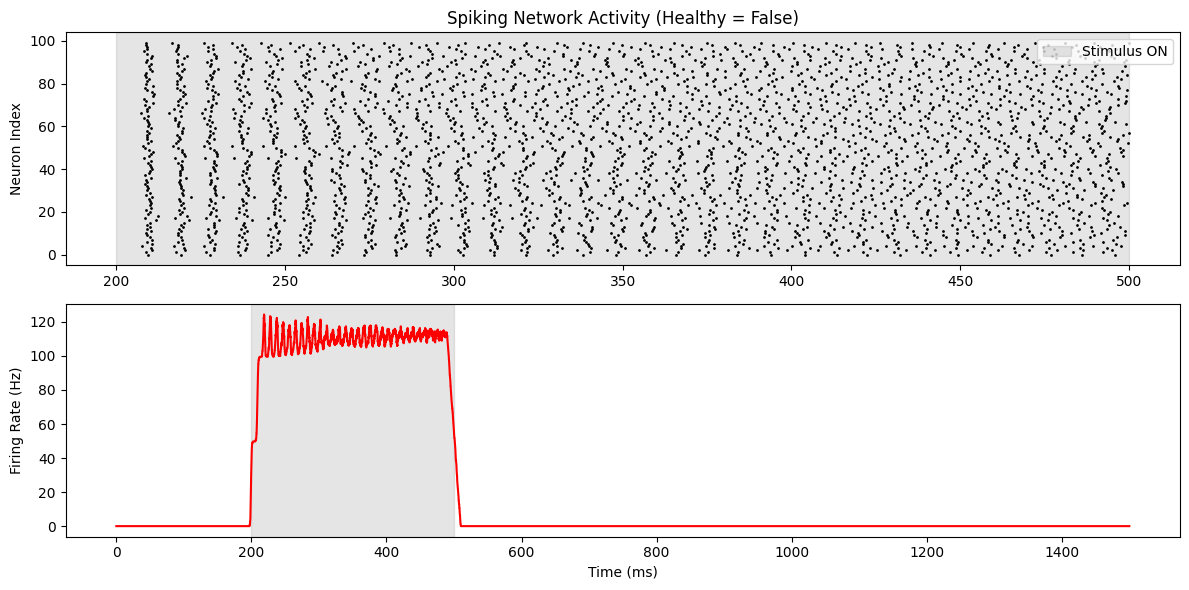

In [27]:
#UNHEALTHY COLLAPSE

from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# Biological Parameters
N = 100
tau_m = 20*ms
v_rest = -65*mV
v_threshold = -50*mV
v_reset = -65*mV
E_exc = 0*mV               
tau_nmda = 100*ms
R = 100*Mohm
sigma = 1.5*mV # The amplitude of our biological noise

# The Condition Toggle
is_healthy = False
nmda_w = 0.0004 if is_healthy else 0.0002

# The Neuron Equations
# xi represents continuous stochastic noise in Brian2
eqs = '''
dv/dt = (v_rest - v + g_nmda * (E_exc - v) + R*I_ext) / tau_m + sigma*xi*tau_m**-0.5 : volt
dg_nmda/dt = -g_nmda / tau_nmda : 1
I_ext : amp
'''

G = NeuronGroup(N, eqs, threshold='v > v_threshold', reset='v = v_reset', method='euler')
G.v = v_rest
G.g_nmda = 0

# Recurrent Connections
S = Synapses(G, G, on_pre='g_nmda += nmda_w')
S.connect(p=0.15)  #PROBABILITY HAS BEEN ALTERED HERE

# Monitors
spikes = SpikeMonitor(G)
rate = PopulationRateMonitor(G)

# Phase A: Rest
G.I_ext = 0*nA
run(200*ms)

# Phase B: The Cue
G.I_ext = 0.4*nA
run(300*ms)

# Phase C: The Delay / Memory Phase
G.I_ext = 0*nA
run(1000*ms)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(spikes.t/ms, spikes.i, '.k', markersize=2)
plt.axvspan(200, 500, color='gray', alpha=0.2, label='Stimulus ON')
plt.title(f'Spiking Network Activity (Healthy = {is_healthy})')
plt.ylabel('Neuron Index')
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
smoothed_rate = rate.smooth_rate(window='flat', width=20.1*ms)
plt.plot(rate.t/ms, smoothed_rate, 'b' if is_healthy else 'r')
plt.axvspan(200, 500, color='gray', alpha=0.2)
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()

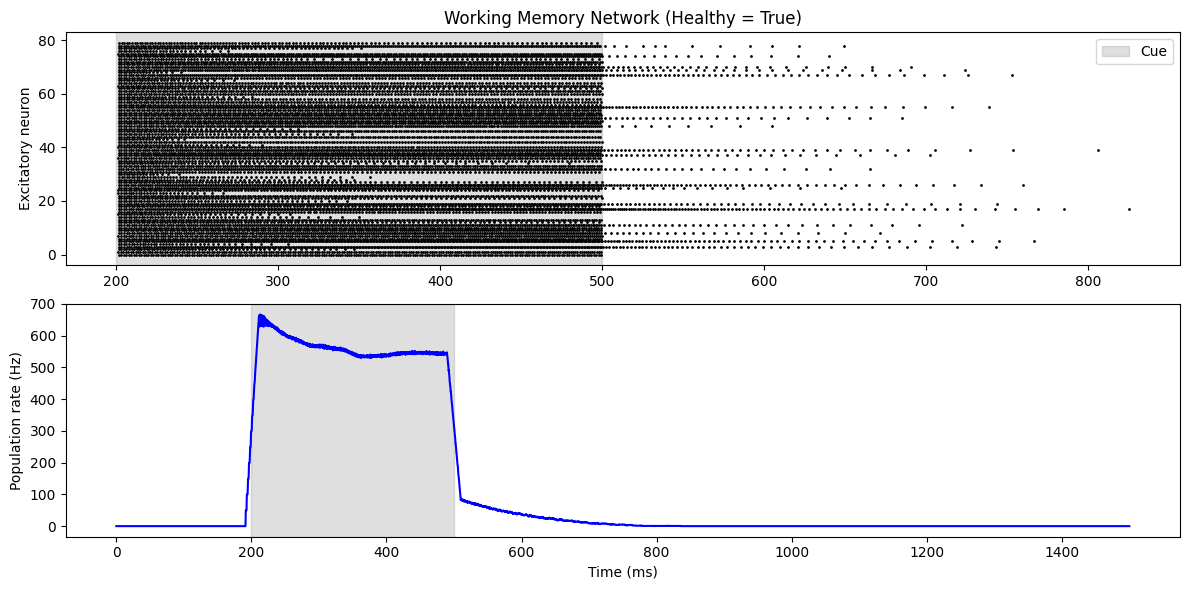

In [5]:
from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# ==========================================================
# Toggle
# ==========================================================

is_healthy = True

# ==========================================================
# Network size
# ==========================================================

N_exc = 80
N_inh = 20

# ==========================================================
# Membrane parameters
# ==========================================================

tau_m = 20*ms

v_rest = -65*mV
v_reset = -65*mV
v_threshold = -50*mV

R = 100*Mohm

# ==========================================================
# Synaptic reversal potentials
# ==========================================================

E_exc = 0*mV
E_inh = -80*mV

# ==========================================================
# Synaptic time constants
# ==========================================================

tau_nmda = 100*ms
tau_gaba = 10*ms

# ==========================================================
# Disease parameters
# ==========================================================

if is_healthy:

    nmda_strength = 0.005
    inhibition_strength = 0.12
    sigma = 1.2*mV

else:

    # NMDA hypofunction
    nmda_strength = 0.002

    # weaker inhibitory recruitment
    inhibition_strength = 0.08

    # noisier cortex
    sigma = 2.2*mV

# ==========================================================
# Neuron equations
# ==========================================================

eqs = '''

dv/dt = (
(v_rest-v)
+ g_nmda*(E_exc-v)
+ g_gaba*(E_inh-v)
+ R*I_ext
)/tau_m
+ sigma*xi*tau_m**-0.5 : volt

dg_nmda/dt = -g_nmda/tau_nmda : 1

dg_gaba/dt = -g_gaba/tau_gaba : 1

I_ext : amp

'''

# ==========================================================
# Populations
# ==========================================================

Exc = NeuronGroup(
    N_exc,
    eqs,
    threshold='v>v_threshold',
    reset='v=v_reset',
    method='euler'
)

Inh = NeuronGroup(
    N_inh,
    eqs,
    threshold='v>v_threshold',
    reset='v=v_reset',
    method='euler'
)

Exc.v = v_rest
Inh.v = v_rest

Exc.I_ext = 0*nA
Inh.I_ext = 0*nA

# ==========================================================
# Recurrent excitation (NMDA)
# ==========================================================

EE = Synapses(
    Exc,
    Exc,
    on_pre=f'g_nmda += {nmda_strength}'
)

EE.connect(p=0.1)

# ==========================================================
# Excitatory → inhibitory
# ==========================================================

EI = Synapses(
    Exc,
    Inh,
    on_pre='g_nmda += 0.04'
)

EI.connect(p=0.1)

# ==========================================================
# Inhibitory → excitatory
# ==========================================================

IE = Synapses(
    Inh,
    Exc,
    on_pre=f'g_gaba += {inhibition_strength}'
)

IE.connect(p=0.1)

# ==========================================================
# Inhibitory recurrent
# ==========================================================

II = Synapses(
    Inh,
    Inh,
    on_pre='g_gaba += 0.05'
)

II.connect(p=0.1)

# ==========================================================
# Background cortical activity
# ==========================================================

background = PoissonGroup(N_exc+N_inh, rates=5*Hz)

bg_exc = Synapses(
    background,
    Exc,
    on_pre='g_nmda += 0.015'
)

bg_exc.connect(j='i if i < N_exc')

bg_inh = Synapses(
    background,
    Inh,
    on_pre='g_nmda += 0.015'
)

bg_inh.connect(j='i-N_exc if i>=N_exc')

# ==========================================================
# Monitors
# ==========================================================

spike_exc = SpikeMonitor(Exc)

rate_exc = PopulationRateMonitor(Exc)

# ==========================================================
# Phase A : Rest
# ==========================================================

run(200*ms)

# ==========================================================
# Phase B : Cue
# ==========================================================

Exc.I_ext = 2*nA

run(300*ms)

# ==========================================================
# Phase C : Delay
# ==========================================================

Exc.I_ext = 0*nA

run(1000*ms)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)

plt.plot(spike_exc.t/ms,
         spike_exc.i,
         '.k',
         markersize=2)

plt.axvspan(
    200,
    500,
    color='gray',
    alpha=0.25,
    label='Cue'
)

plt.ylabel("Excitatory neuron")

plt.title(
    f"Working Memory Network (Healthy = {is_healthy})"
)

plt.legend()

plt.subplot(2,1,2)

smooth = rate_exc.smooth_rate(
    window='flat',
    width=20*ms
)

if is_healthy:
    plt.plot(rate_exc.t/ms, smooth, 'b')
else:
    plt.plot(rate_exc.t/ms, smooth, 'r')

plt.axvspan(
    200,
    500,
    color='gray',
    alpha=0.25
)

plt.xlabel("Time (ms)")
plt.ylabel("Population rate (Hz)")

plt.tight_layout()
plt.show()

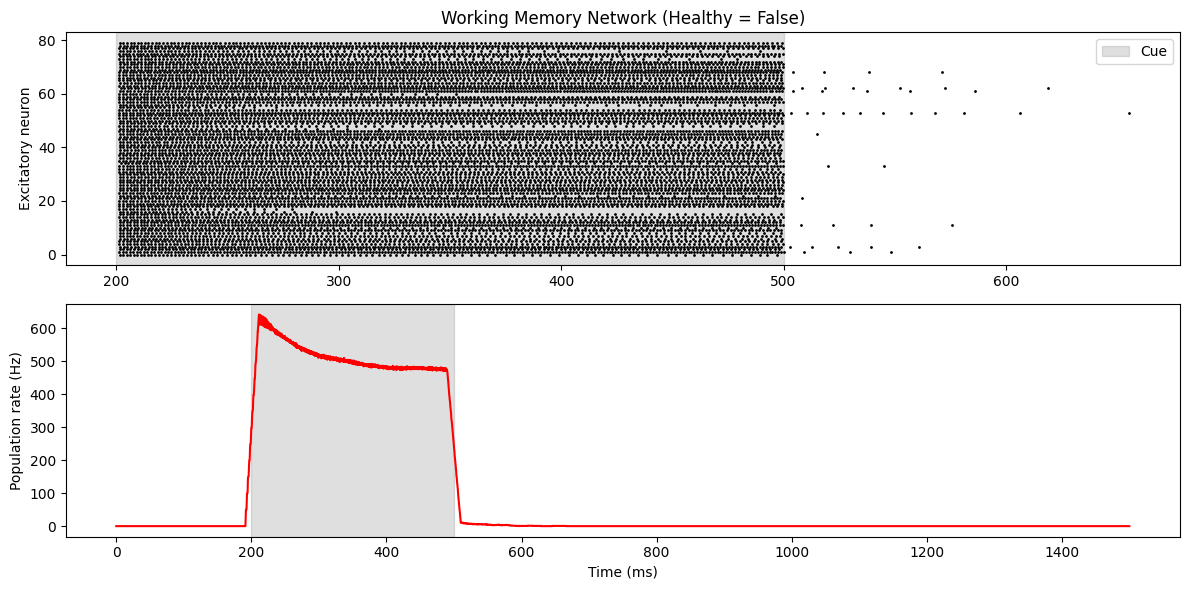

In [6]:
from brian2 import *
import matplotlib.pyplot as plt

prefs.codegen.target = 'numpy'
start_scope()

# ==========================================================
# Toggle
# ==========================================================

is_healthy = False

# ==========================================================
# Network size
# ==========================================================

N_exc = 80
N_inh = 20

# ==========================================================
# Membrane parameters
# ==========================================================

tau_m = 20*ms

v_rest = -65*mV
v_reset = -65*mV
v_threshold = -50*mV

R = 100*Mohm

# ==========================================================
# Synaptic reversal potentials
# ==========================================================

E_exc = 0*mV
E_inh = -80*mV

# ==========================================================
# Synaptic time constants
# ==========================================================

tau_nmda = 100*ms
tau_gaba = 10*ms

# ==========================================================
# Disease parameters
# ==========================================================

if is_healthy:

    nmda_strength = 0.005
    inhibition_strength = 0.12
    sigma = 1.2*mV

else:

    # NMDA hypofunction
    nmda_strength = 0.002

    # weaker inhibitory recruitment
    inhibition_strength = 0.08

    # noisier cortex
    sigma = 2.2*mV

# ==========================================================
# Neuron equations
# ==========================================================

eqs = '''

dv/dt = (
(v_rest-v)
+ g_nmda*(E_exc-v)
+ g_gaba*(E_inh-v)
+ R*I_ext
)/tau_m
+ sigma*xi*tau_m**-0.5 : volt

dg_nmda/dt = -g_nmda/tau_nmda : 1

dg_gaba/dt = -g_gaba/tau_gaba : 1

I_ext : amp

'''

# ==========================================================
# Populations
# ==========================================================

Exc = NeuronGroup(
    N_exc,
    eqs,
    threshold='v>v_threshold',
    reset='v=v_reset',
    method='euler'
)

Inh = NeuronGroup(
    N_inh,
    eqs,
    threshold='v>v_threshold',
    reset='v=v_reset',
    method='euler'
)

Exc.v = v_rest
Inh.v = v_rest

Exc.I_ext = 0*nA
Inh.I_ext = 0*nA

# ==========================================================
# Recurrent excitation (NMDA)
# ==========================================================

EE = Synapses(
    Exc,
    Exc,
    on_pre=f'g_nmda += {nmda_strength}'
)

EE.connect(p=0.1)

# ==========================================================
# Excitatory → inhibitory
# ==========================================================

EI = Synapses(
    Exc,
    Inh,
    on_pre='g_nmda += 0.04'
)

EI.connect(p=0.1)

# ==========================================================
# Inhibitory → excitatory
# ==========================================================

IE = Synapses(
    Inh,
    Exc,
    on_pre=f'g_gaba += {inhibition_strength}'
)

IE.connect(p=0.1)

# ==========================================================
# Inhibitory recurrent
# ==========================================================

II = Synapses(
    Inh,
    Inh,
    on_pre='g_gaba += 0.05'
)

II.connect(p=0.1)

# ==========================================================
# Background cortical activity
# ==========================================================

background = PoissonGroup(N_exc+N_inh, rates=5*Hz)

bg_exc = Synapses(
    background,
    Exc,
    on_pre='g_nmda += 0.015'
)

bg_exc.connect(j='i if i < N_exc')

bg_inh = Synapses(
    background,
    Inh,
    on_pre='g_nmda += 0.015'
)

bg_inh.connect(j='i-N_exc if i>=N_exc')

# ==========================================================
# Monitors
# ==========================================================

spike_exc = SpikeMonitor(Exc)

rate_exc = PopulationRateMonitor(Exc)

# ==========================================================
# Phase A : Rest
# ==========================================================

run(200*ms)

# ==========================================================
# Phase B : Cue
# ==========================================================

Exc.I_ext = 2*nA

run(300*ms)

# ==========================================================
# Phase C : Delay
# ==========================================================

Exc.I_ext = 0*nA

run(1000*ms)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)

plt.plot(spike_exc.t/ms,
         spike_exc.i,
         '.k',
         markersize=2)

plt.axvspan(
    200,
    500,
    color='gray',
    alpha=0.25,
    label='Cue'
)

plt.ylabel("Excitatory neuron")

plt.title(
    f"Working Memory Network (Healthy = {is_healthy})"
)

plt.legend()

plt.subplot(2,1,2)

smooth = rate_exc.smooth_rate(
    window='flat',
    width=20*ms
)

if is_healthy:
    plt.plot(rate_exc.t/ms, smooth, 'b')
else:
    plt.plot(rate_exc.t/ms, smooth, 'r')

plt.axvspan(
    200,
    500,
    color='gray',
    alpha=0.25
)

plt.xlabel("Time (ms)")
plt.ylabel("Population rate (Hz)")

plt.tight_layout()
plt.show()